--- Stage 1: Loading and Processing Data ---
Successfully loaded JSON file from: C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\processed data\json_2408\patches_coco_with_original_bbox.json
Successfully processed 10860 annotations.

--- Stage 2: Preparing Data for Binary Classification ---
Data split into 7602 training and 3258 testing samples.
Class distribution in training data:
binary_class
0    0.696001
1    0.303999
Name: proportion, dtype: float64

Optimizing binary model with GridSearchCV...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Optimization complete.
Best parameters found: {'criterion': 'gini', 'max_depth': 5, 'n_estimators': 200}

--- Stage 3: Evaluating the Binary Classifier ---

Classification Report:
              precision    recall  f1-score   support

       other       0.87      0.40      0.55      2268
     rbc/cbc       0.39      0.86      0.53       990

    accuracy                           0.54      3258
   macro avg       0.

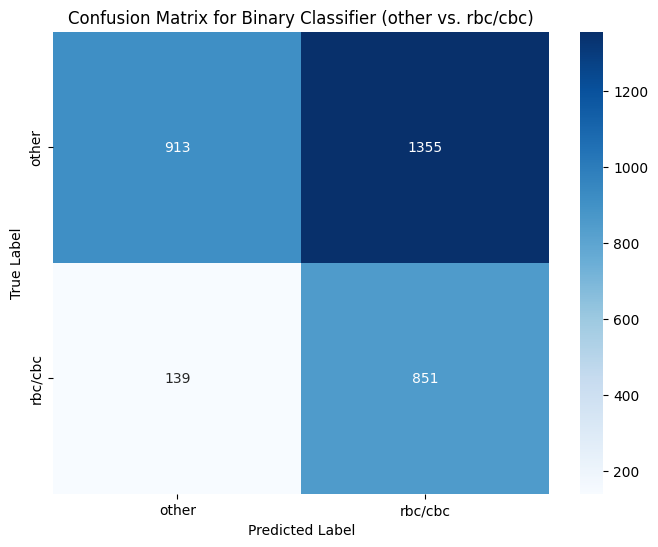

In [1]:
# ─── 1) Imports & Setup ───────────────────────────────────────────
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ─── 2) File Path ────────────────────────────────────────────────
JSON_PATH = r'C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\processed data\json_2408\patches_coco_with_original_bbox.json'


# ─── 3) Load and Process Data ───────────────────────────────────────
print("--- Stage 1: Loading and Processing Data ---")
try:
    with open(JSON_PATH, 'r') as f:
        coco_data = json.load(f)
    print(f"Successfully loaded JSON file from: {JSON_PATH}")
except FileNotFoundError:
    print(f"--- ERROR: FILE NOT FOUND ---")
    coco_data = None

if coco_data and coco_data.get('annotations'):
    annotations = coco_data['annotations']
    data_list = []
    for ann in annotations:
        if 'original_bbox' in ann and ann['original_bbox']:
            min_y, _, max_y, _ = ann['original_bbox']
            height = max_y - min_y
            data_list.append({
                'height': height,
                'class_id': ann['category_id']
            })

    df = pd.DataFrame(data_list)
    print(f"Successfully processed {len(df)} annotations.")
    
    # ─── 4) Model Training and Optimization (BINARY CLASSIFICATION) ───
    print("\n--- Stage 2: Preparing Data for Binary Classification ---")

    # ★★★★★★★★★★★★★★★★★★★★★★★★★★★★ KEY CHANGE HERE ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
    # Create a new target column for binary classification.
    # Class 0 ('other') maps to 0.
    # Classes 1 ('rbc') and 2 ('cbc') are combined and map to 1.
    df['binary_class'] = df['class_id'].apply(lambda x: 0 if x == 0 else 1)
    # ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
    
    BINARY_CLASS_MAP = {0: 'other', 1: 'rbc/cbc'}
    
    # Prepare data: Feature (X) is height, Target (y) is the new binary_class
    X = df[['height']]
    y = df['binary_class']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    print(f"Data split into {len(X_train)} training and {len(X_test)} testing samples.")
    print(f"Class distribution in training data:\n{y_train.value_counts(normalize=True)}")

    model = RandomForestClassifier(random_state=42, class_weight='balanced')
    
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 20],
        'criterion': ['gini', 'entropy']
    }

    # Optimize for F1-score, which is excellent for binary classification
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1, scoring='f1')
    
    print("\nOptimizing binary model with GridSearchCV...")
    grid_search.fit(X_train, y_train)

    print("\nOptimization complete.")
    print(f"Best parameters found: {grid_search.best_params_}")
    best_model = grid_search.best_estimator_

    # ─── 5) Model Evaluation ────────────────────────────────────────────
    print("\n--- Stage 3: Evaluating the Binary Classifier ---")
    y_pred = best_model.predict(X_test)

    print("\nClassification Report:")
    report = classification_report(y_test, y_pred, target_names=BINARY_CLASS_MAP.values())
    print(report)

    print("Generating confusion matrix plot...")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=BINARY_CLASS_MAP.values(), yticklabels=BINARY_CLASS_MAP.values())
    plt.title('Confusion Matrix for Binary Classifier (other vs. rbc/cbc)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig('binary_height_classifier_confusion_matrix.png')
    print("Saved confusion matrix plot to 'binary_height_classifier_confusion_matrix.png'")
    print("\n--- Analysis Complete ---")